In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import seaborn as sns

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

import warnings
warnings.filterwarnings('ignore')

In [2]:
product, time_reso, reso = 'IMERG', '1dy', '10'

In [3]:
dir_input = os.path.join('/','media','arturo','T9','Data','INTENSE','Satellite','2_MEV', 'uncorrected')
dir_output = os.path.join('/','media','arturo','T9','Data','INTENSE','Satellite','2_MEV', 'corrected')
obs_base = os.path.join('/','media','arturo','T9','Data','INTENSE','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [4]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
lon_min, lon_max, lat_min, lat_max, area = 12.25, 14, 45.5, 46.65, 'Friuli-Venezia Giulia'

In [5]:
# yys, yye = 2002, 2022
yys, yye = 2009, 2022

In [6]:
inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
DATA = xr.open_dataset(os.path.join(dir_input, 'quantiles_v2', inputfile))

DATA = DATA.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max),
    year=slice(yys, yye)
)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

MEV = DATA.Mev_s.where(mask_italy).values

In [7]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))

METADATA['Yr_Strt'] = pd.to_datetime(METADATA['Yr_Strt'])
METADATA['Yer_End'] = pd.to_datetime(METADATA['Yer_End'])

METADATA['YYs'] = METADATA['Yr_Strt'].dt.year
METADATA['YYe'] = METADATA['Yer_End'].dt.year
METADATA['Nyear'] = (METADATA['YYe']-METADATA['YYs'])+1

METADATA_CLEAR = METADATA[(METADATA['YYs'] <= yys)&(METADATA['YYe'] >= yye)]

# METADATA_CLEAR = METADATA_CLEAR[METADATA_CLEAR.Nyear>19]

METADATA_CLEAR = METADATA_CLEAR[METADATA_CLEAR['Region']=='Friuli-Venezia Giulia']

print(f'Number of Stations filtered: {len(METADATA_CLEAR)}')

Number of Stations filtered: 159


Text(0, 0.5, 'Rain Gauges')

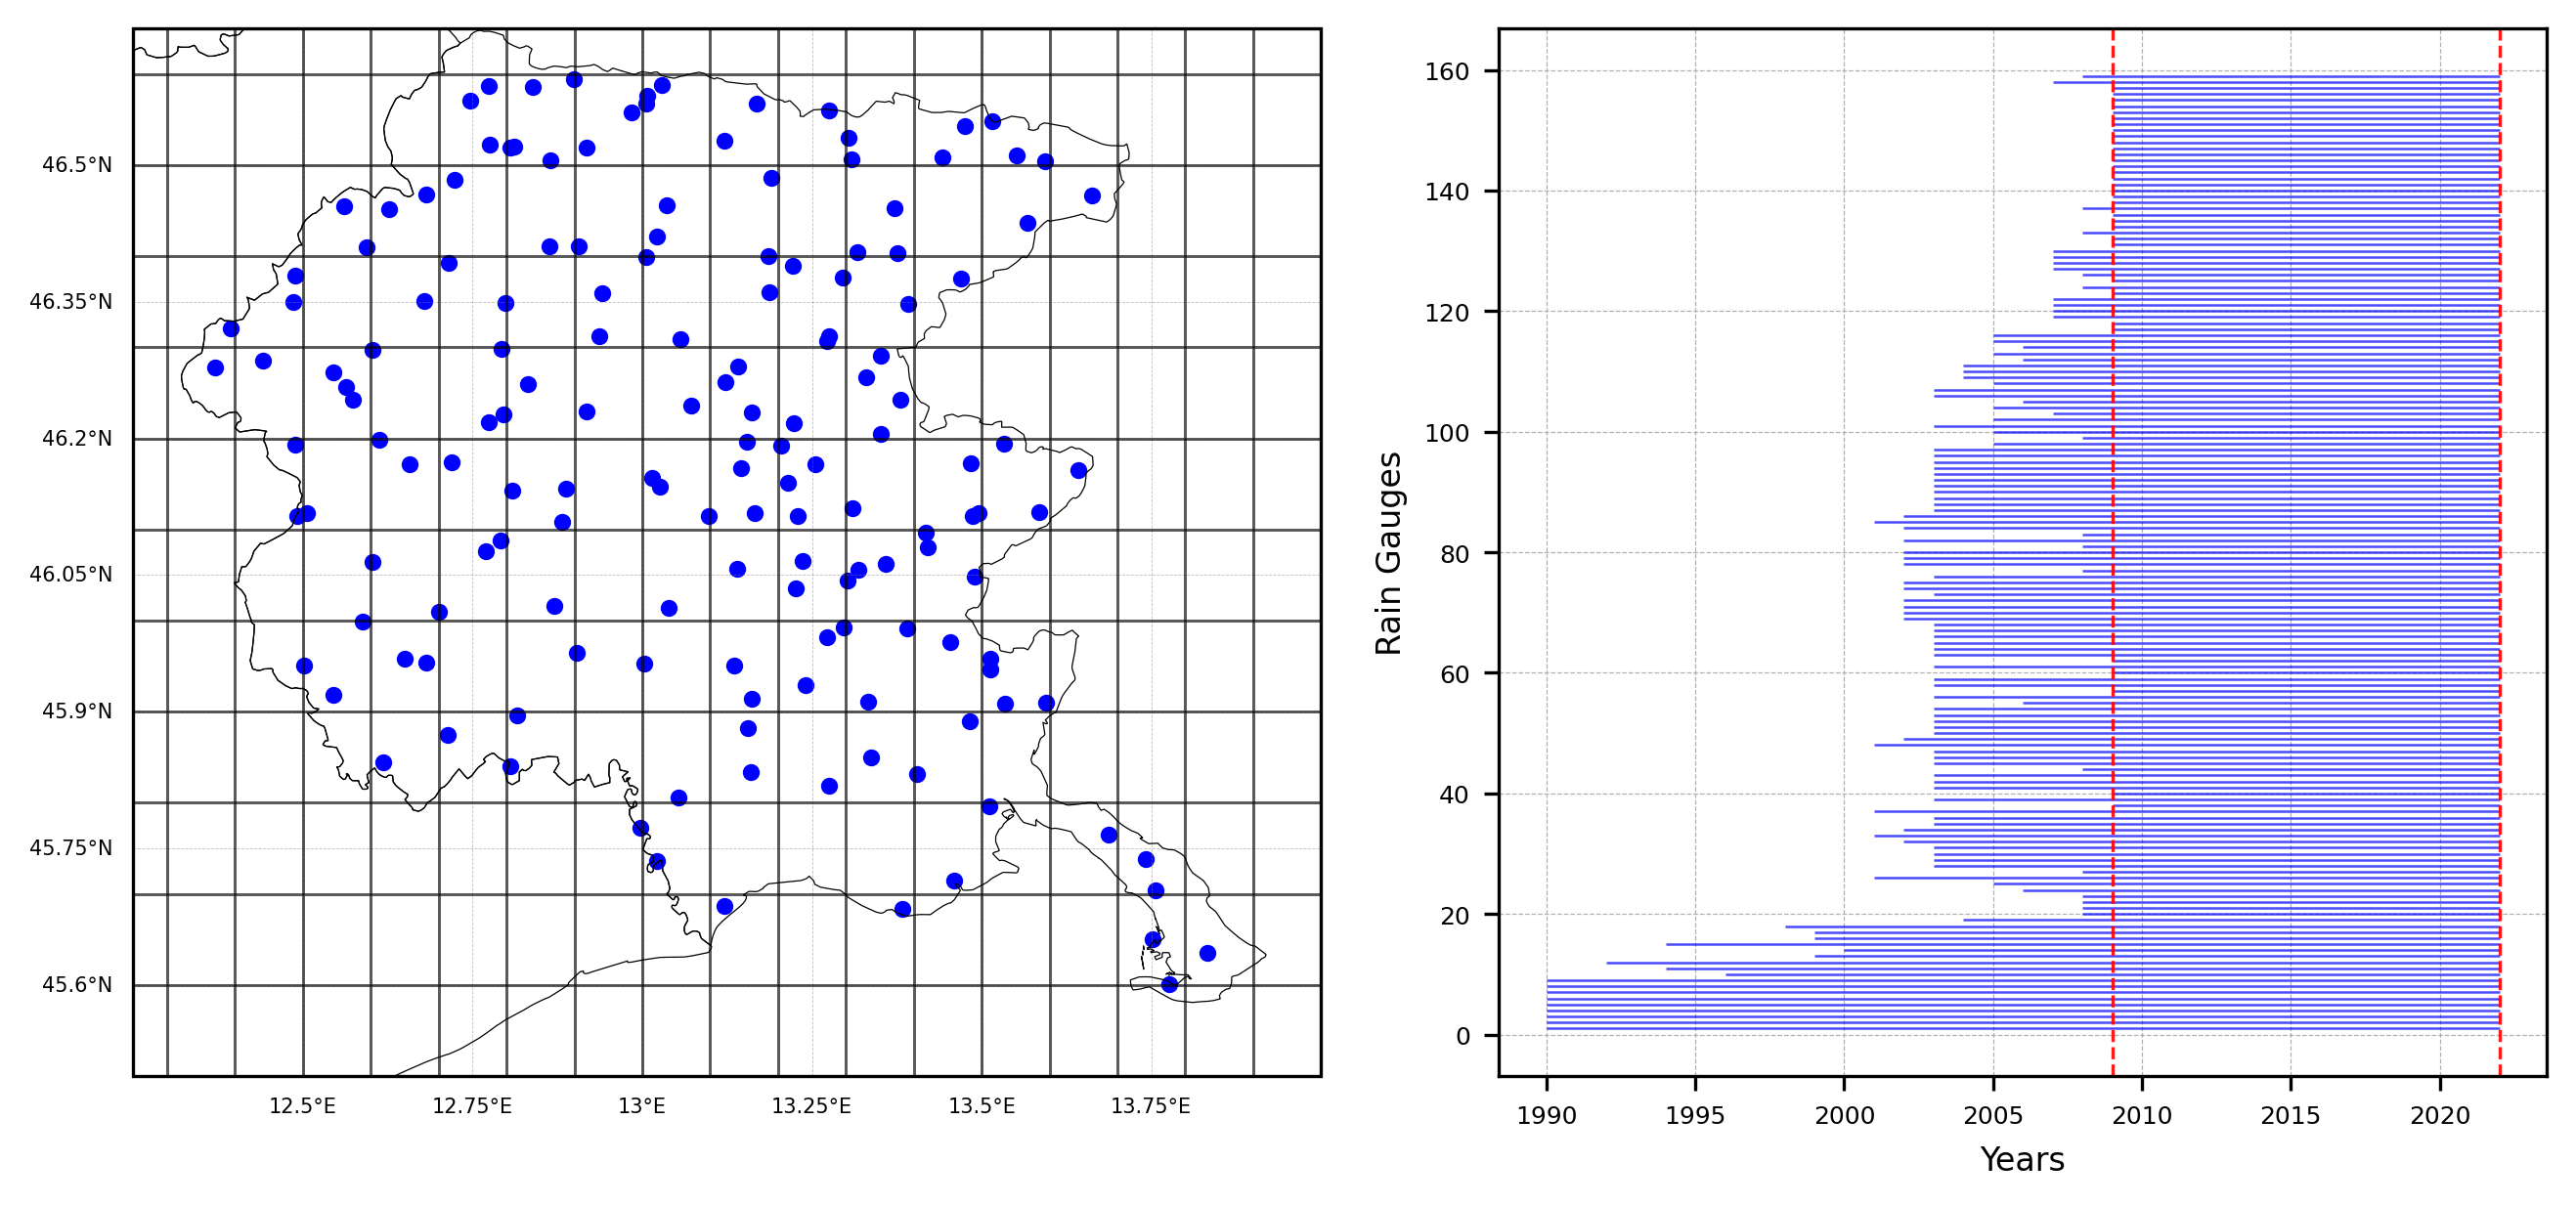

In [8]:
factor_levels = np.arange(0,2.5,0.1)
factor_norm = mcolors.BoundaryNorm(boundaries=factor_levels, ncolors=256)

zeros = np.zeros(lon2d.shape)

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 4), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
# ax00.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.scatter(METADATA_CLEAR.Lon.values, METADATA_CLEAR.Lat.values, s=10, c='b', cmap='Spectral', norm=factor_norm)

ax00.pcolormesh(
    lon2d, lat2d, zeros,
    transform=ccrs.PlateCarree(),  # O la proyección geográfica de lons/lats
    facecolor='none',               # Mantiene la celda transparente
    edgecolor='k',               # Color de las líneas de la grilla
    linewidth=0.3,                 # Grosor de la línea
    alpha=0.4,                     # Transparencia
    zorder=3
)

gl = ax00.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 5, 'color': 'k'}
gl.ylabel_style = {'size': 5, 'color': 'k'}

# ========================================================================================================
ax01 = fig.add_subplot(gs[0, 1])
ax01.set_box_aspect(1)
for i in range(len(METADATA_CLEAR)):
    ax01.hlines(
        y=i+1,
        xmin=METADATA_CLEAR.YYs.values[i],
        xmax=METADATA_CLEAR.YYe.values[i],
        color='b',
        linewidth=0.6,
        alpha=0.7)

ax01.axvline(yys, color='r',linestyle='--',linewidth=0.8,alpha=0.9,label=f'{yys}/01/01')
ax01.axvline(yye, color='r',linestyle='--',linewidth=0.8,alpha=0.9,label=f'{yye}/12/31')

# ax01.set_xlim(yys-2,yye+2)
ax01.grid(linewidth=0.3, linestyle='--')
ax01.tick_params(axis='both', which='major', labelsize=6)
ax01.set_xlabel('Years',fontsize=8)
ax01.set_ylabel('Rain Gauges',fontsize=8)

In [9]:
pos = 3
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)
print(f'Return Time: {Tr[pos]} yrs')

Return Time: 50 yrs


In [10]:
for nn in range(len(METADATA_CLEAR)):

    file = METADATA_CLEAR['File'].values[nn]
    ISO = METADATA_CLEAR['ISO'].values[nn]
    lon_obs = METADATA_CLEAR['Lon'].values[nn]
    lat_obs = METADATA_CLEAR['Lat'].values[nn]

    DF_OBS = pd.read_csv(os.path.join(obs_base,'Weibull','1dy',ISO,file)) 
    DF_OBS = DF_OBS.drop(columns='NaN')

    sat_pixel = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

    sat_n = sat_pixel.NYs.values
    sat_year = sat_pixel.year.values

    DF_SAT = pd.DataFrame({'Year':sat_pixel.year.values, 'Ns':sat_pixel.NYs.values, 'Cs':sat_pixel.CYs.values, 'Ws':sat_pixel.WYs.values})

    merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')
    # merged_df_clean = merged_df.dropna(subset=['N'])
    
    merged_df['lon'] = lon_obs
    merged_df['lat'] = lat_obs


In [11]:
factor_N_annual = []
factor_C_annual = []
factor_W_annual = []

for nn in range(len(METADATA_CLEAR)):

    file = METADATA_CLEAR['File'].iloc[nn]
    ISO = METADATA_CLEAR['ISO'].iloc[nn]
    lon_obs = METADATA_CLEAR['Lon'].iloc[nn]
    lat_obs = METADATA_CLEAR['Lat'].iloc[nn]

    # Observations
    DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

    DF_OBS = DF_OBS.drop(columns='NaN')

    # IMERG nearest pixel
    sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

    DF_SAT = pd.DataFrame({'Year': sat_pixel.year.values,'Ns': sat_pixel.NYs.values,'Cs': sat_pixel.CYs.values,'Ws': sat_pixel.WYs.values})

    # Merge by year
    merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

    merged_df_clean = merged_df.dropna(subset=['N', 'C', 'W', 'Ns', 'Cs', 'Ws'])

    # Annual correction factors
    merged_df_clean['factor_N'] = (merged_df_clean['N'] / merged_df_clean['Ns'])
    merged_df_clean['factor_C'] = (merged_df_clean['C'] / merged_df_clean['Cs'])
    merged_df_clean['factor_W'] = (merged_df_clean['W'] / merged_df_clean['Ws'])

    # Add spatial information
    merged_df_clean['lon'] = lon_obs
    merged_df_clean['lat'] = lat_obs

    # Store only the required columns
    factor_N_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_N']])
    factor_C_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_C']])
    factor_W_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_W']])

In [12]:
Factor_N_annual_df = pd.concat(factor_N_annual,ignore_index=True)
Factor_C_annual_df = pd.concat(factor_C_annual,ignore_index=True)
Factor_W_annual_df = pd.concat(factor_W_annual,ignore_index=True)

In [13]:
years = np.arange(yys, yye+1)

factor_N_grids = []
factor_C_grids = []
factor_W_grids = []

for year in years:

    print(f'Interpolating year: {year}')

    # Select one year
    Factor_N_year = Factor_N_annual_df[
        Factor_N_annual_df['Year'] == year
    ][['lon', 'lat', 'factor_N']].copy()

    Factor_C_year = Factor_C_annual_df[
        Factor_C_annual_df['Year'] == year
    ][['lon', 'lat', 'factor_C']].copy()

    Factor_W_year = Factor_W_annual_df[
        Factor_W_annual_df['Year'] == year
    ][['lon', 'lat', 'factor_W']].copy()

    # Rename factor columns
    Factor_N_year = Factor_N_annual_df[
        Factor_N_annual_df['Year'] == year
    ][['lon', 'lat', 'factor_N']].rename(
        columns={'factor_N': 'factor'}
    )

    Factor_C_year = Factor_C_annual_df[
        Factor_C_annual_df['Year'] == year
    ][['lon', 'lat', 'factor_C']].rename(
        columns={'factor_C': 'factor'}
    )

    Factor_W_year = Factor_W_annual_df[
        Factor_W_annual_df['Year'] == year
    ][['lon', 'lat', 'factor_W']].rename(
        columns={'factor_W': 'factor'}
    )

    # Interpolation
    factor_N_grid_year = (
        ART_stat.interpolate_factors_to_grid(
            Factor_N_year,
            DATA,
            use_idw=True,
            power=2,
            n_neighbors=2,
            max_distance=5.0
        )
        .where(mask_italy)
    )

    factor_C_grid_year = (
        ART_stat.interpolate_factors_to_grid(
            Factor_C_year,
            DATA,
            use_idw=True,
            power=2,
            n_neighbors=2,
            max_distance=5.0
        )
        .where(mask_italy)
    )

    factor_W_grid_year = (
        ART_stat.interpolate_factors_to_grid(
            Factor_W_year,
            DATA,
            use_idw=True,
            power=2,
            n_neighbors=2,
            max_distance=5.0
        )
        .where(mask_italy)
    )

    factor_N_grids.append(factor_N_grid_year)
    factor_C_grids.append(factor_C_grid_year)
    factor_W_grids.append(factor_W_grid_year)

Interpolating year: 2009
Interpolating year: 2010
Interpolating year: 2011
Interpolating year: 2012
Interpolating year: 2013
Interpolating year: 2014
Interpolating year: 2015
Interpolating year: 2016
Interpolating year: 2017
Interpolating year: 2018
Interpolating year: 2019
Interpolating year: 2020
Interpolating year: 2021
Interpolating year: 2022


In [14]:
factor_N_grid = xr.concat(factor_N_grids,dim=pd.Index(years, name='year'))
factor_C_grid = xr.concat(factor_C_grids,dim=pd.Index(years, name='year'))
factor_W_grid = xr.concat(factor_W_grids,dim=pd.Index(years, name='year'))

In [15]:
NYs = DATA.NYs.where(mask_italy)
CYs = DATA.CYs.where(mask_italy)
WYs = DATA.WYs.where(mask_italy)

In [16]:
NY_corrected = NYs * factor_N_grid
CY_corrected = CYs * factor_C_grid
WY_corrected = WYs * factor_W_grid

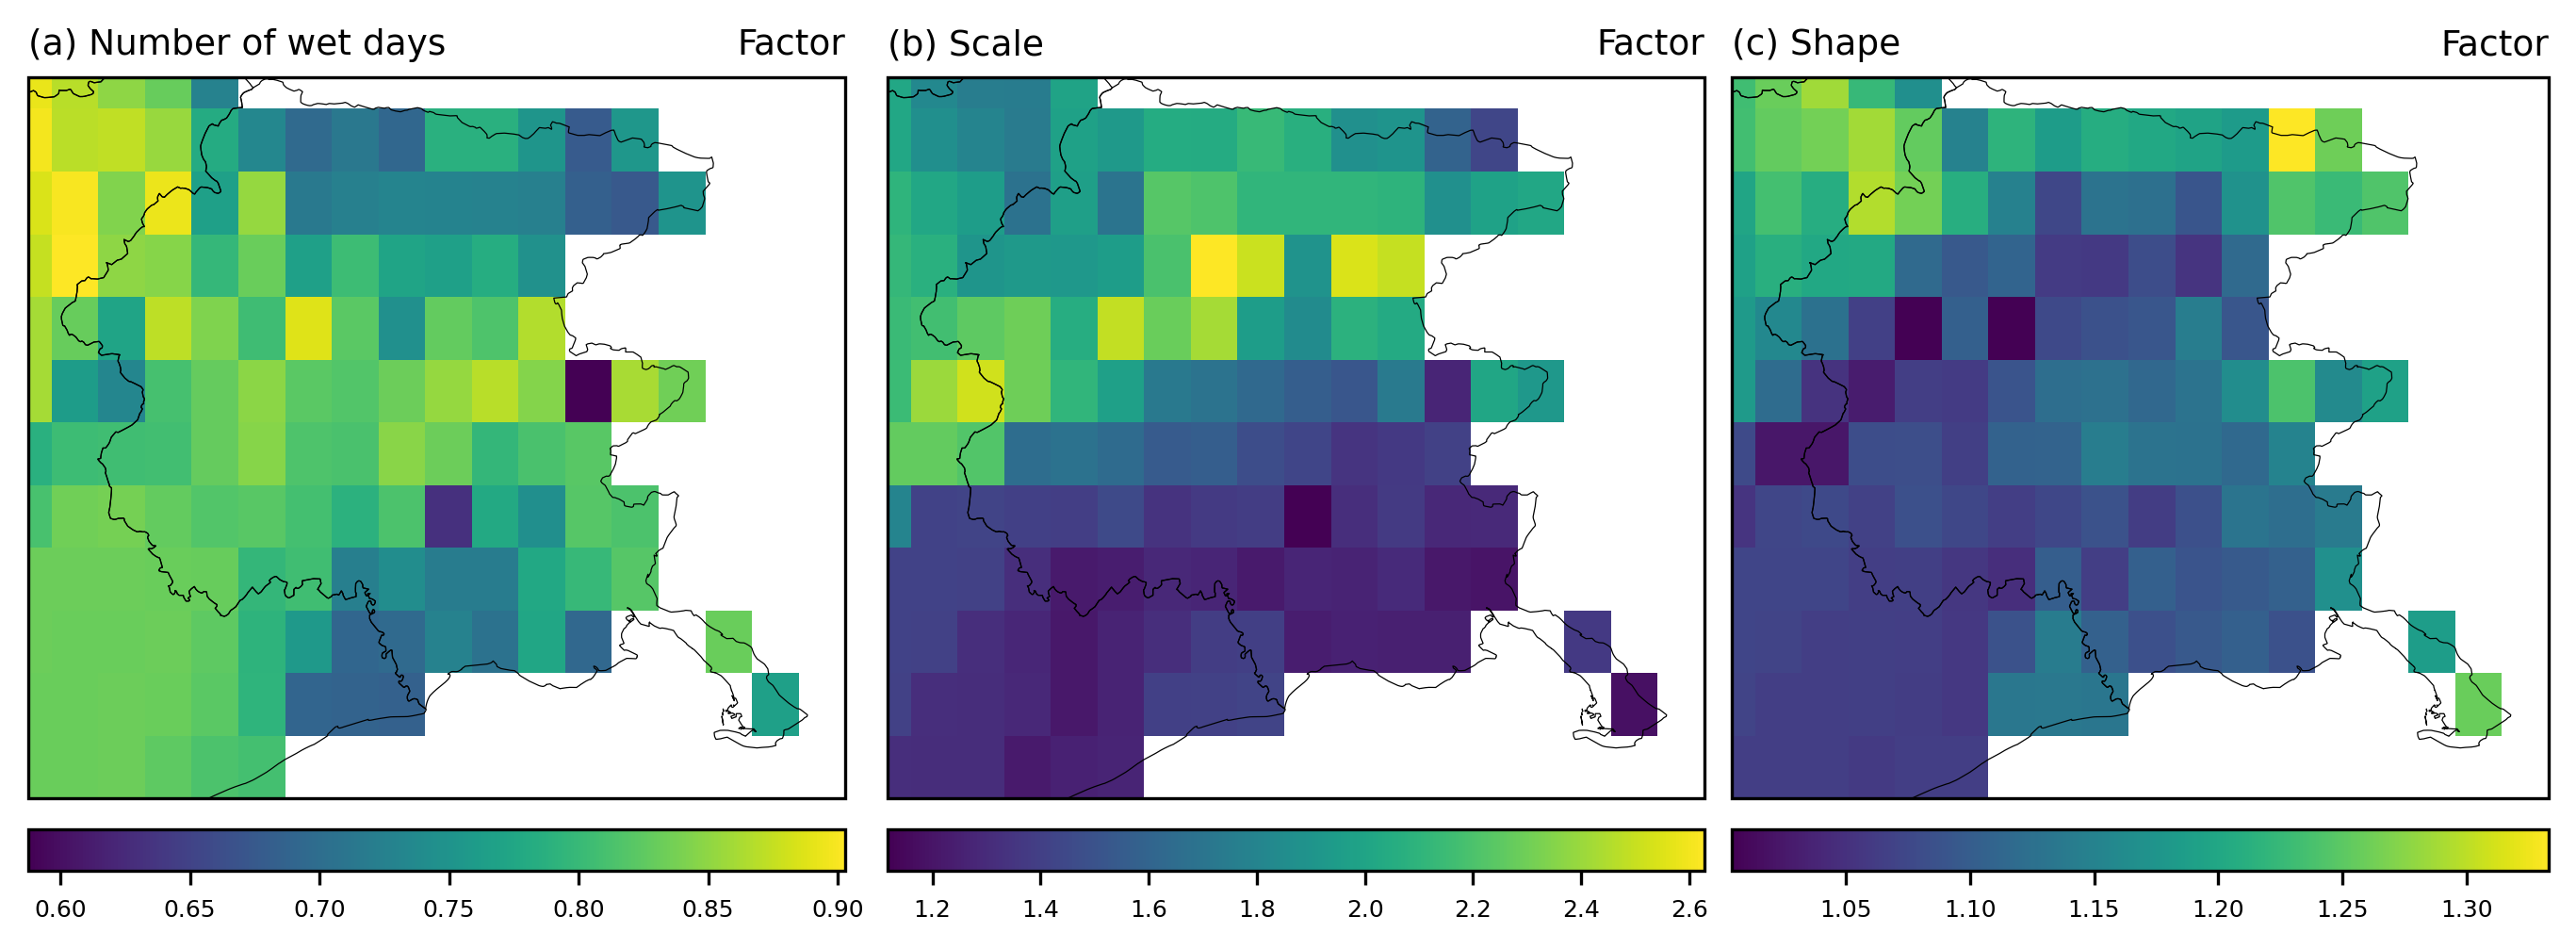

In [69]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 4), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 3, figure=fig)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(factor_N_grid,axis=0))
ax00.set_title('(a) Number of wet days',fontsize=9,loc='left')
ax00.set_title('Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 1], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(factor_C_grid,axis=0))
ax00.set_title('(b) Scale',fontsize=9,loc='left')
ax00.set_title('Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 2], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(factor_W_grid,axis=0))
ax00.set_title('(c) Shape',fontsize=9,loc='left')
ax00.set_title('Factor',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

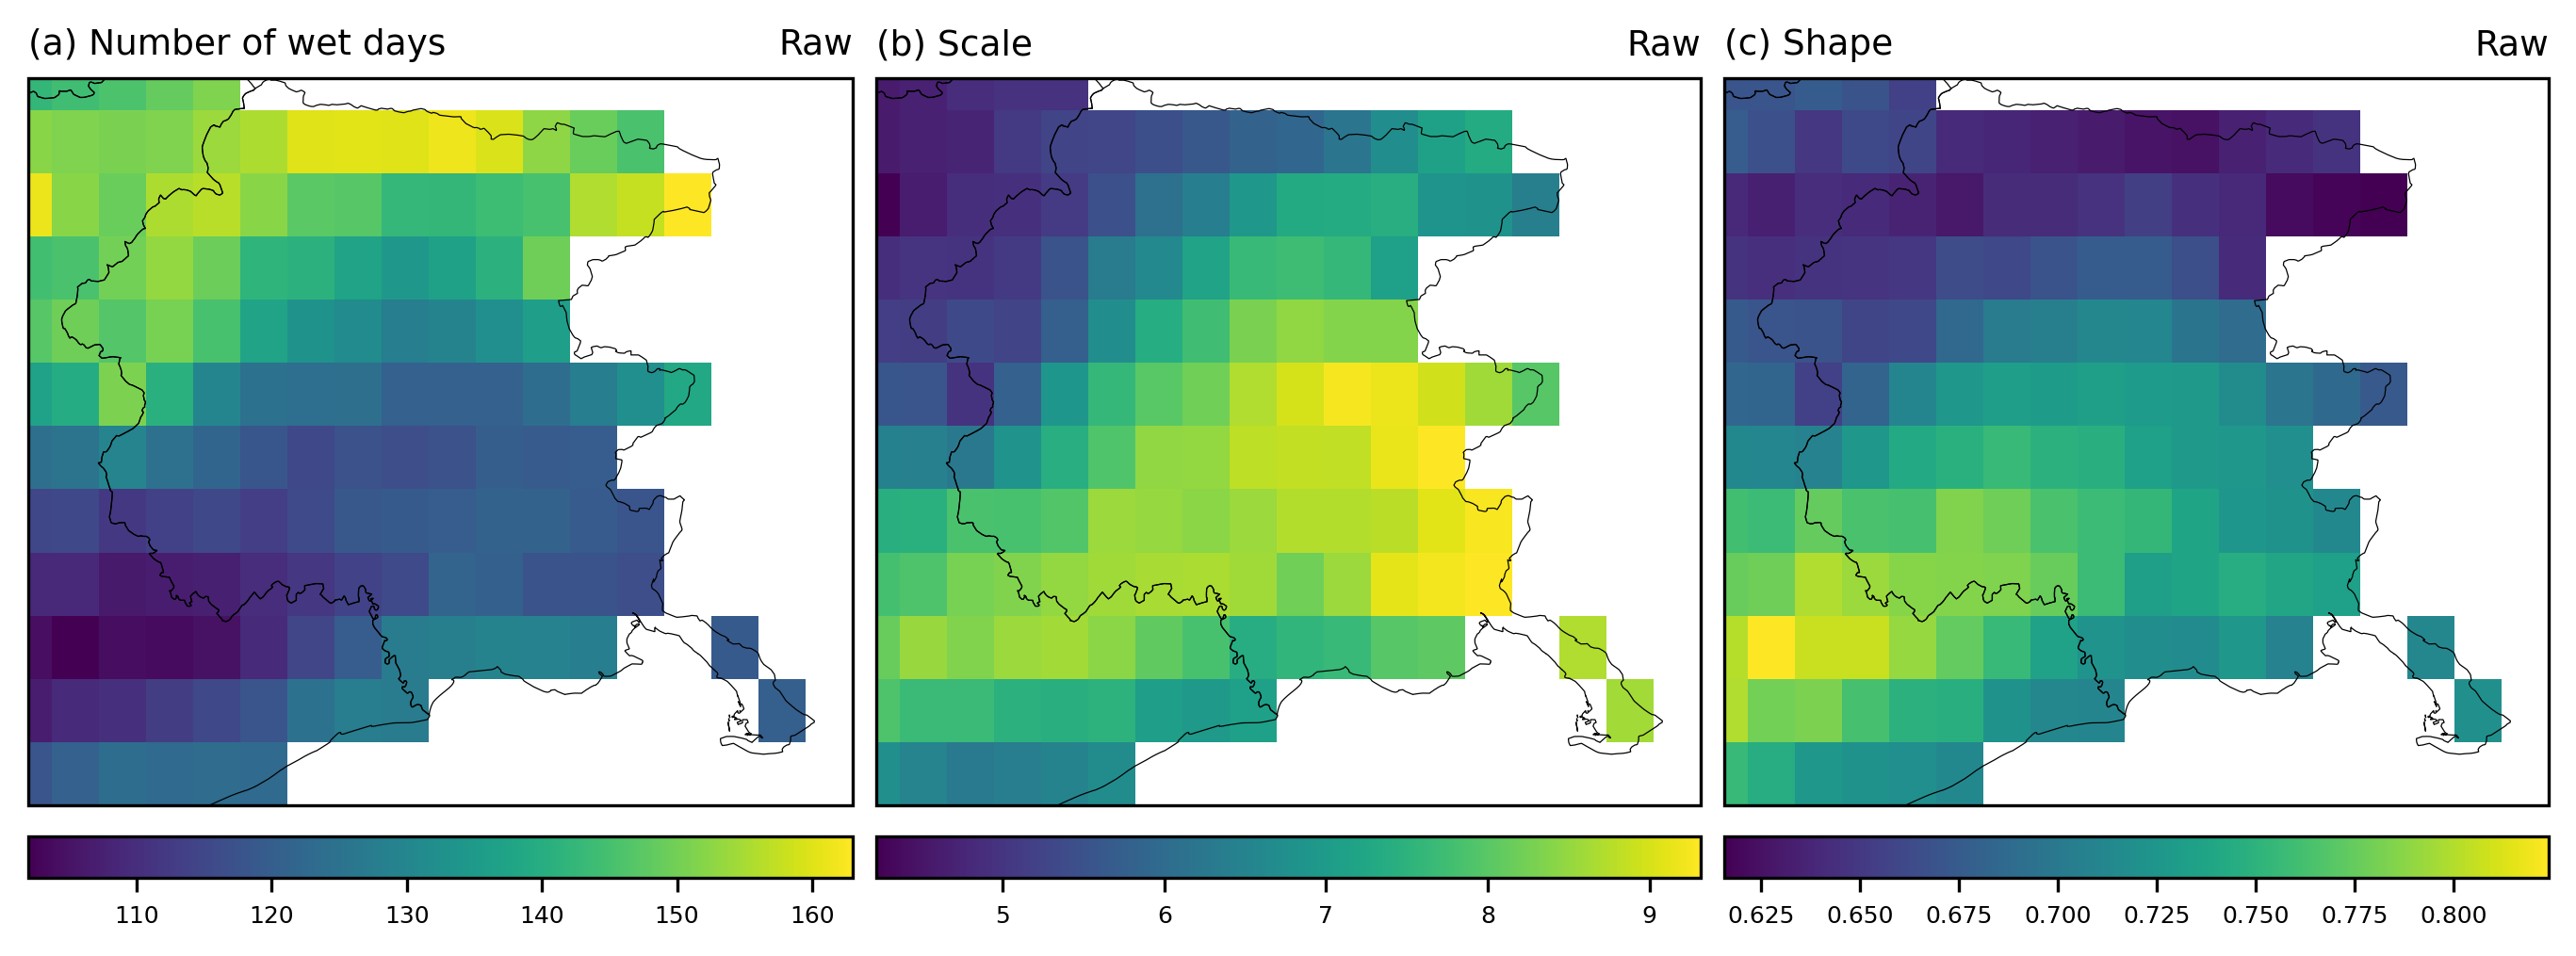

In [65]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 4), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 3, figure=fig)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(NYs.values,axis=0))
ax00.set_title('(a) Number of wet days',fontsize=9,loc='left')
ax00.set_title('Raw',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 1], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(CYs.values,axis=0))
ax00.set_title('(b) Scale',fontsize=9,loc='left')
ax00.set_title('Raw',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 2], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(WYs.values,axis=0))
ax00.set_title('(c) Shape',fontsize=9,loc='left')
ax00.set_title('Raw',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

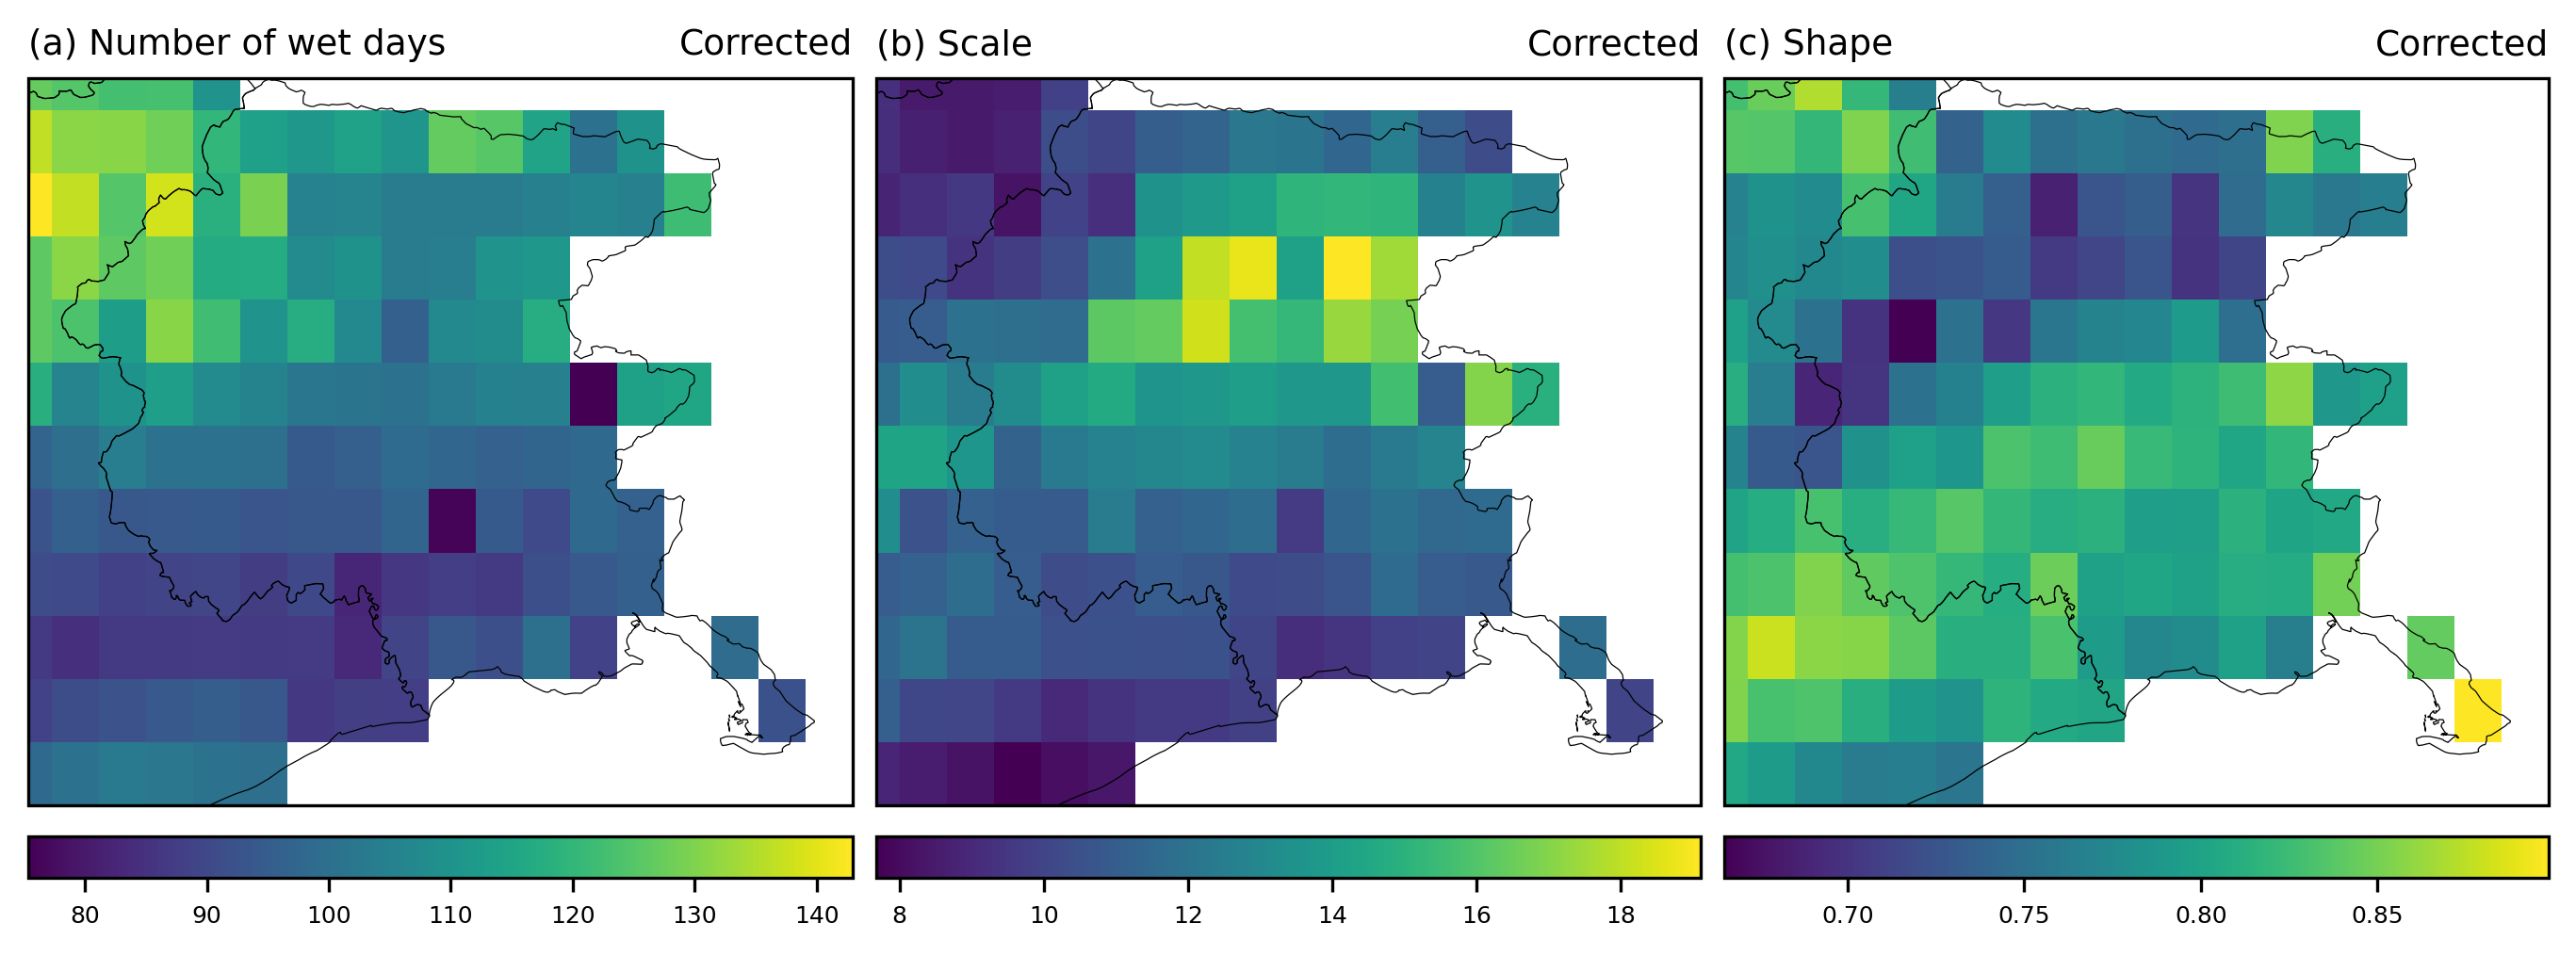

In [66]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 4), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(1, 3, figure=fig)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 0], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(NY_corrected.values,axis=0))
ax00.set_title('(a) Number of wet days',fontsize=9,loc='left')
ax00.set_title('Corrected',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 1], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(CY_corrected.values,axis=0))
ax00.set_title('(b) Scale',fontsize=9,loc='left')
ax00.set_title('Corrected',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

#==================================================================================================
ax00 = fig.add_subplot(gs[0, 2], projection=proj)
ax00.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax00, zorder=10)
a1 = ax00.pcolormesh(lon2d, lat2d, np.nanmean(WY_corrected.values,axis=0))
ax00.set_title('(c) Shape',fontsize=9,loc='left')
ax00.set_title('Corrected',fontsize=9,loc='right')
cbar = plt.colorbar(a1, fraction=0.05, orientation='horizontal', pad=0.03, ticks=None)
cbar.ax.tick_params(labelsize=6)

In [34]:
RE = []
Nobs_all, Cobs_all, Wobs_all = [], [], []
Ncor_all, Ccor_all, Wcor_all = [], [], []

for nn in range(len(METADATA_CLEAR)):

    lon_obs = METADATA_CLEAR['Lon'].iloc[nn]
    lat_obs = METADATA_CLEAR['Lat'].iloc[nn]

    # Seleccionar el píxel IMERG más cercano
    sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

    # Seleccionar el mismo píxel en los campos corregidos
    N_corrected_station = NY_corrected.sel(lat=sat_pixel.lat,lon=sat_pixel.lon,method='nearest')

    C_corrected_station = CY_corrected.sel(lat=sat_pixel.lat,lon=sat_pixel.lon,method='nearest')

    W_corrected_station = WY_corrected.sel(lat=sat_pixel.lat,lon=sat_pixel.lon,method='nearest')

    # Leer datos observados
    file = METADATA_CLEAR['File'].iloc[nn]
    ISO = METADATA_CLEAR['ISO'].iloc[nn]

    DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

    DF_OBS = DF_OBS.drop(columns='NaN')

    # Crear DataFrame con los parámetros corregidos
    comparison = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

    # Añadir parámetros observados
    comparison = comparison.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
    comparison = comparison.dropna()

    Nobs_all.extend(comparison.N.values)
    Cobs_all.extend(comparison.C.values)
    Wobs_all.extend(comparison.W.values)
    
    Ncor_all.extend(comparison.N_corrected.values)
    Ccor_all.extend(comparison.C_corrected.values)
    Wcor_all.extend(comparison.W_corrected.values)

    x0 = np.nanmean(comparison.C.values)
    Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison.N.values, comparison.C.values, comparison.W.values, thresh=1)

    x0 = np.nanmean(comparison.C_corrected.values)
    Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison.N_corrected.values, comparison.C_corrected.values, comparison.W_corrected.values, thresh=1)

    RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
    RE.append(RE_)

In [32]:
comparison.head(3)

,Year,N_corrected,C_corrected,W_corrected,N,C,W
0,2009,111.881137,15.409732,0.703911,110.0,15.665073,0.710548
1,2010,111.524780,19.107916,0.799577,112.0,18.622574,0.817230
2,2011,91.544465,14.655562,0.765042,90.0,14.726128,0.782900


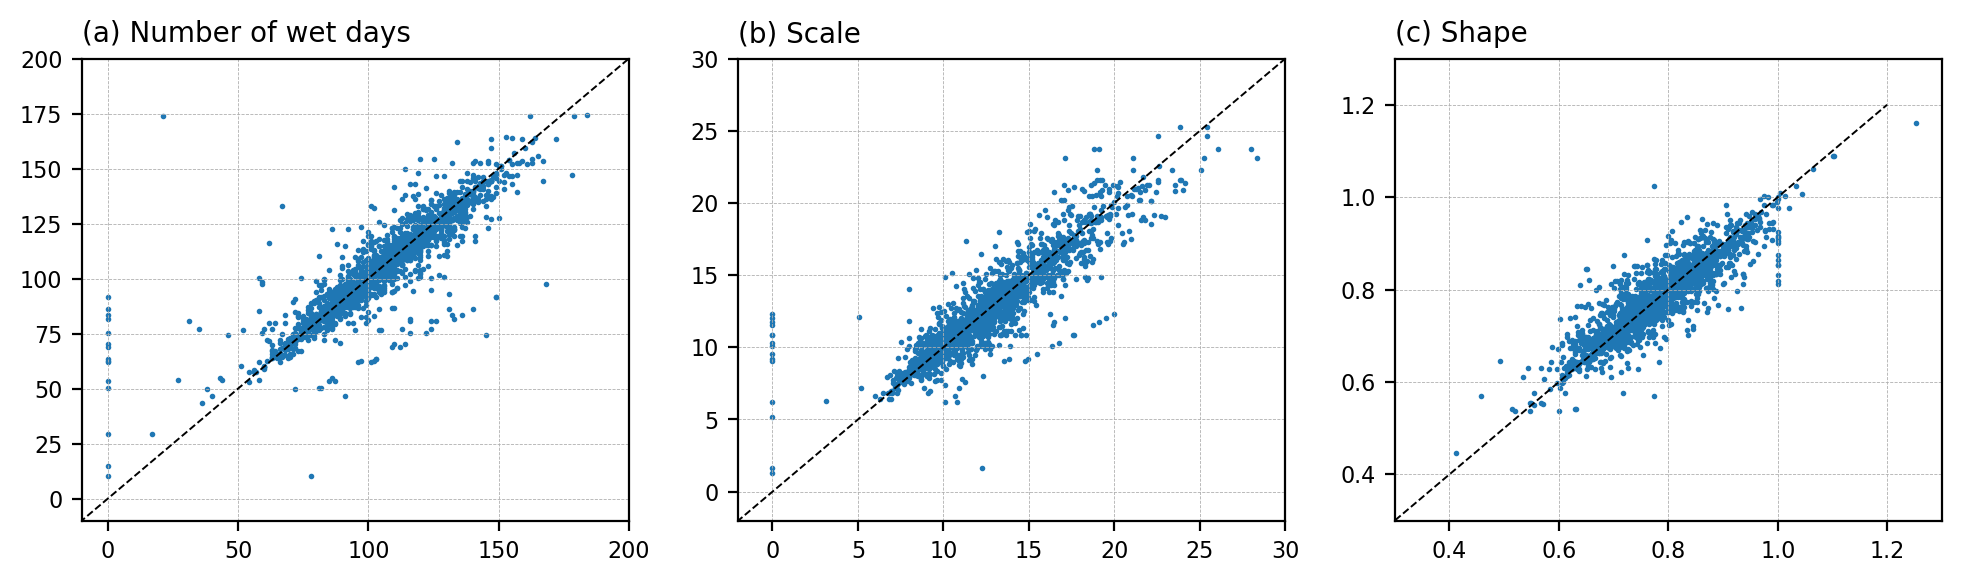

In [51]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(12,3),dpi=200)
gs = gridspec.GridSpec(1,3)

# ===================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.scatter(Nobs_all, Ncor_all, s=1)

xx = np.arange(-20, 220)
ax1.plot(xx,xx,linewidth=0.7,linestyle='--',c='k')

ax1.set_xlim(-10,200)
ax1.set_ylim(-10,200)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(a) Number of wet days',fontsize=10, loc='left')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.scatter(Cobs_all, Ccor_all, s=1)

xx = np.arange(-3, 33)
ax1.plot(xx,xx,linewidth=0.7,linestyle='--',c='k')

ax1.set_xlim(-2,30)
ax1.set_ylim(-2,30)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(b) Scale',fontsize=10, loc='left')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===================================================================
ax1 = plt.subplot(gs[0, 2])
ax1.scatter(Wobs_all, Wcor_all, s=1)

xx = np.arange(0.2, 1.4)
ax1.plot(xx,xx,linewidth=0.7,linestyle='--',c='k')

ax1.set_xlim(0.3,1.3)
ax1.set_ylim(0.3,1.3)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('(c) Shape',fontsize=10, loc='left')
ax1.tick_params(axis='both', which='major', labelsize=8)

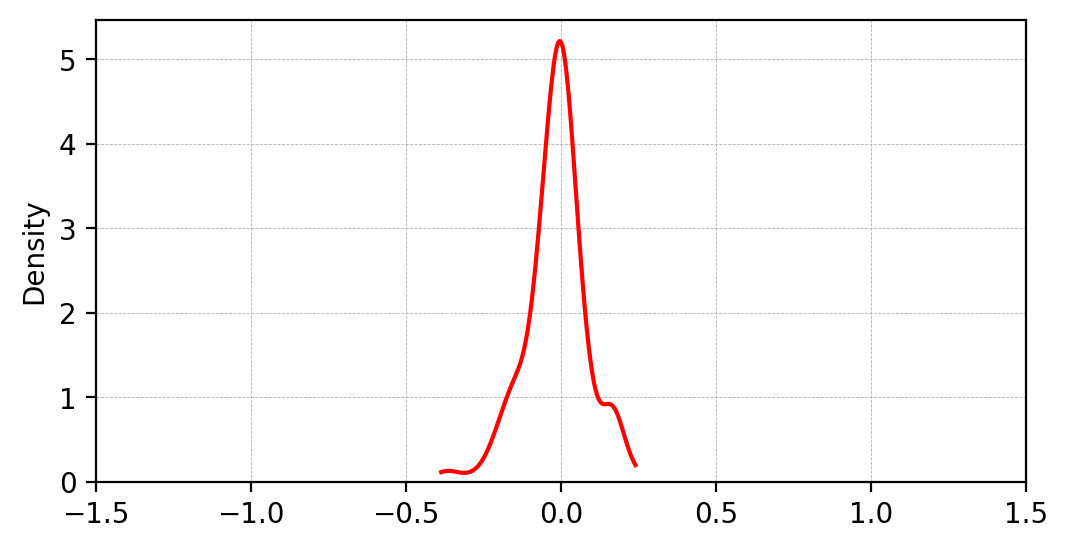

In [47]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6,3),dpi=200)
gs = gridspec.GridSpec(1,1)

ax1 = plt.subplot(gs[0, 0])
sns.kdeplot(RE,color='r', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'SAT',
            clip=(np.nanmin(np.array(RE)), np.nanmax(np.array(RE))))

ax1.set_xlim(-1.5,1.5)
ax1.grid(linewidth=0.3, linestyle='--')

In [28]:
nn = 155

lon_obs = METADATA_CLEAR['Lon'].iloc[nn]
lat_obs = METADATA_CLEAR['Lat'].iloc[nn]

# Seleccionar el píxel IMERG más cercano
sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

# Seleccionar el mismo píxel en los campos corregidos
N_corrected_station = NY_corrected.sel(lat=sat_pixel.lat,lon=sat_pixel.lon,method='nearest')

C_corrected_station = CY_corrected.sel(lat=sat_pixel.lat,lon=sat_pixel.lon,method='nearest')

W_corrected_station = WY_corrected.sel(lat=sat_pixel.lat,lon=sat_pixel.lon,method='nearest')

# Leer datos observados
file = METADATA_CLEAR['File'].iloc[nn]
ISO = METADATA_CLEAR['ISO'].iloc[nn]

DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

DF_OBS = DF_OBS.drop(columns='NaN')

# Crear DataFrame con los parámetros corregidos
comparison = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

# Añadir parámetros observados
comparison = comparison.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
comparison = comparison.dropna()

x0 = np.nanmean(comparison.C.values)
Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison.N.values, comparison.C.values, comparison.W.values, thresh=1)

x0 = np.nanmean(comparison.C_corrected.values)
Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison.N_corrected.values, comparison.C_corrected.values, comparison.W_corrected.values, thresh=1)
RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
print(Q_obs[0][3],Q_corrected[0][3],RE_)

478.4211370599868 376.03322941033645 -0.21401209043322944
